### Import packages

In [1]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

### Import chunked_paragraphs_with_embeddings_uncer df

In [2]:
chunked_pg_w_embed_uncert = pd.read_csv("data_files/chunked_paragraphs_with_embeddings_uncert.csv")

chunked_pg_w_embed_uncert = chunked_pg_w_embed_uncert[
    chunked_pg_w_embed_uncert["subcategory"].astype(str).str.strip().str.lower()
    ==
    chunked_pg_w_embed_uncert["matched_phrase"].astype(str).str.strip().str.lower()
].copy()

print(chunked_pg_w_embed_uncert["subcategory"].unique())

chunked_pg_w_embed_uncert.head(5)

['Nondefense Discretionary' 'Social Security' 'Medicaid' 'Net Interest'
 'Medicare' 'Other Mandatory' 'Total Discretionary'
 'Defense Discretionary' 'Total Mandatory']


,report_name,paragraph_number,text,subcategory,row_id,match_method,matched_phrase,category,component,contextual_uncertainty_score
0,2000-01-01__12069__The Budget and Economic Out...,10,Dan L. Crippen Director January 2000 This stud...,Nondefense Discretionary,9,direct_phrase_w2v_neighbors,Nondefense Discretionary,Discretionary,outlay,0.022607
6,2000-01-01__12069__The Budget and Economic Out...,19,"Regardless of the variant, the budgetary pictu...",Social Security,18,direct_phrase_w2v_neighbors,Social Security,Mandatory,outlay,0.021429
28,2000-01-01__12069__The Budget and Economic Out...,49,Discretionary spending is projected to increas...,Nondefense Discretionary,48,direct_phrase_w2v_neighbors,Nondefense Discretionary,Discretionary,outlay,0.016471
40,2000-01-01__12069__The Budget and Economic Out...,83,To illustrate the possible effects of differen...,Medicaid,82,direct_phrase_w2v_neighbors,Medicaid,Mandatory,outlay,0.092086
46,2000-01-01__12069__The Budget and Economic Out...,89,CBO’s latest budget outlook is considerably mo...,Net Interest,88,direct_phrase_w2v_neighbors,Net Interest,Net Interest,outlay,0.019937


### Import CBO projection errors df from GitHub 

In [3]:
proj_errors = pd.read_csv("https://raw.githubusercontent.com/US-CBO/eval-projections/main/output_data/outlay_projection_errors.csv")
proj_errors["abs_projection_error"] = proj_errors["projection_error"].abs()
proj_errors

,component,category,subcategory,baseline_date,Spring_flag,Winter_flag,projected_fiscal_year,projected_year_number,value,actual_value,GDP,legislative_outlay_change,adjusted_projection,projection_error,projection_error_pct_actual,leg_change_pct_GDP,projection_error_pct_GDP,abs_projection_error
0,outlay,Total,Total,1984-02-01,True,False,1984,1,867.600,851.805,3949.175,0.258,867.858,16.053,1.885,0.007,0.406,16.053
1,outlay,Total,Total,1985-02-01,True,False,1985,1,949.658,946.344,4265.125,1.373,951.031,4.687,0.495,0.032,0.110,4.687
2,outlay,Total,Total,1986-02-01,True,False,1986,1,986.697,990.382,4526.250,-4.162,982.535,-7.847,-0.792,-0.092,-0.173,7.847
3,outlay,Total,Total,1987-02-01,True,False,1987,1,1009.838,1004.017,4767.650,3.156,1012.994,8.977,0.894,0.066,0.188,8.977
4,outlay,Total,Total,1988-03-01,True,False,1988,1,1059.306,1064.416,5138.550,0.054,1059.360,-5.056,-0.475,0.001,-0.098,5.056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2941,outlay,Net Interest,Net Interest,2011-03-01,True,False,2021,11,806.563,352.338,23044.050,138.007,944.570,592.232,168.086,0.599,2.570,592.232
2942,outlay,Net Interest,Net Interest,2012-03-01,True,False,2022,11,604.222,475.887,25565.375,279.144,883.366,407.479,85.625,1.092,1.594,407.479
2943,outlay,Net Interest,Net Interest,2013-05-01,True,False,2023,11,822.962,658.267,27397.950,111.485,934.447,276.180,41.956,0.407,1.008,276.180
2944,outlay,Net Interest,Net Interest,2014-04-01,True,False,2024,11,876.263,879.879,28947.900,148.001,1024.264,144.385,16.410,0.511,0.499,144.385


### Merge chunked_pg_w_embed_uncert and proj_errors

In [4]:
# 1. Parse the Baseline Year from the CBO GitHub DataFrame
# Using errors='coerce' to safely handle formatting and .dt.year to isolate the Year
proj_errors['temp_baseline_dt'] = pd.to_datetime(proj_errors['baseline_date'], errors='coerce')
proj_errors['baseline_year'] = proj_errors['temp_baseline_dt'].dt.year

# 2. Extract the Publication Year from your updated uncertainty DataFrame
# Extract 'YYYY' directly from the start of the 'report_name' string using regex
year_pattern = r'^(\d{4})'
chunked_pg_w_embed_uncert['report_year'] = chunked_pg_w_embed_uncert['report_name'].str.extract(year_pattern)[0]

# Convert report_year to numeric/integer to ensure clean data types for merging
chunked_pg_w_embed_uncert['report_year'] = pd.to_numeric(chunked_pg_w_embed_uncert['report_year'], errors='coerce')

# 3. Clean up the subcategory strings to prevent case-sensitivity or whitespace match failures
proj_errors['subcategory'] = proj_errors['subcategory'].astype(str).str.strip().str.lower()
chunked_pg_w_embed_uncert['subcategory'] = chunked_pg_w_embed_uncert['subcategory'].astype(str).str.strip().str.lower()

# 4. Perform the Merge on Year and Subcategory
# Matching 'report_year' from uncertainty to 'baseline_year' from the GitHub errors
merged_df = pd.merge(
    chunked_pg_w_embed_uncert,
    proj_errors[['baseline_year', 'subcategory', 'projected_fiscal_year', 'abs_projection_error']],
    left_on=['report_year', 'subcategory'],
    right_on=['baseline_year', 'subcategory'],
    how='inner'  # Swap to 'left' if you want to keep text chunks without error metrics
)

# 5. Calculate the Forecast Horizon Column (Year Difference)
merged_df['projected_fiscal_year'] = pd.to_numeric(merged_df['projected_fiscal_year'], errors='coerce')

# Horizon = Target Projection Year - Baseline Publication Year
merged_df['projection_horizon_years'] = merged_df['projected_fiscal_year'] - merged_df['report_year']

# 6. Post-Merge Clean Up
# Added errors='ignore' so it won't crash if your update removed/changed these columns
columns_to_drop = ['baseline_year', 'extracted_date', 'temp_datetime', 'year_month_key']
merged_df = merged_df.drop(columns=columns_to_drop, errors='ignore')

# Display a preview of the clean structure
print(f"Merge complete. Row count: {len(merged_df)}")
merged_df[['report_name', 'subcategory', 'projected_fiscal_year', 'projection_horizon_years', 'abs_projection_error']].head()


Merge complete. Row count: 36088


,report_name,subcategory,projected_fiscal_year,projection_horizon_years,abs_projection_error
0,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2000,0,13.415
1,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2001,1,4.696
2,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2002,2,2.649
3,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2003,3,6.871
4,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2004,4,12.100


In [5]:
# Drop any subcategory that contains "total" or "other" (case-insensitive)
mask_drop = merged_df["subcategory"].astype(str).str.contains(r"(total|other)", case=False, na=False)

merged_df = merged_df[~mask_drop].copy()

# Check remaining subcategories
merged_df["subcategory"].unique()

merged_df.to_csv('data_files/projection_error_uncertainty.csv')

C:\Users\ericsc\AppData\Local\Temp\ipykernel_31720\807336085.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_drop = merged_df["subcategory"].astype(str).str.contains(r"(total|other)", case=False, na=False)


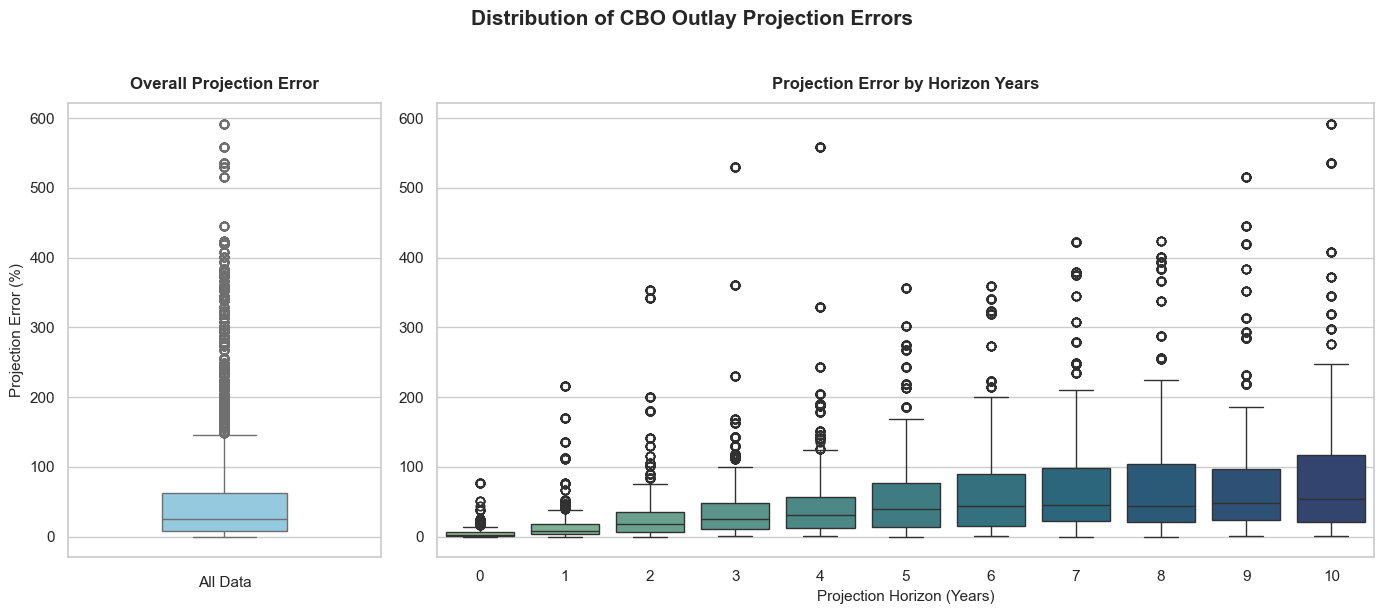

In [6]:
# Get descriptive statistics for projection error
# All df
merged_df['abs_projection_error'].describe()

# By projection_horizon_years
merged_df.groupby('projection_horizon_years')['abs_projection_error'].describe()

# Visualize the two descriptive statistics above
# 1. Set a style for the plots
sns.set_theme(style="whitegrid")

# 2. Create a figure with two side-by-side subplots
# Gridspec_kw adjusts the relative width so the grouped plot on the right has more breathing room
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(14, 6), 
    gridspec_kw={'width_ratios': [1, 3]}
)

# Left Plot: Overall Distribution of Projection Error ---
sns.boxplot(
    data=merged_df, 
    y='abs_projection_error', 
    ax=axes[0], 
    color='skyblue',
    width=0.4
)
axes[0].set_title('Overall Projection Error', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Projection Error (%)', fontsize=11)
axes[0].set_xlabel('All Data', fontsize=11)


# Right Plot: Projection Error by Horizon Year ---
sns.boxplot(
    data=merged_df, 
    x='projection_horizon_years', 
    y='abs_projection_error', 
    ax=axes[1], 
    palette='crest'  # Generates a beautiful gradient showing the horizon progression
)
axes[1].set_title('Projection Error by Horizon Years', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Projection Horizon (Years)', fontsize=11)
axes[1].set_ylabel('')  # Hide y-label on the right plot since it shares the same scale as the left


# --- Adjust Layout & Show Plot ---
plt.suptitle('Distribution of CBO Outlay Projection Errors', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Calculating correlation between uncertainty and projection errors

CORRELATION ANALYSIS RESULTS
Pearson Correlation Coefficient: 0.0338
Pearson p-value:                8.6058e-10 (Statistically Significant)
--------------------------------------------------
Spearman Rank Correlation:       0.0445
Spearman p-value:               6.1153e-16 (Statistically Significant)


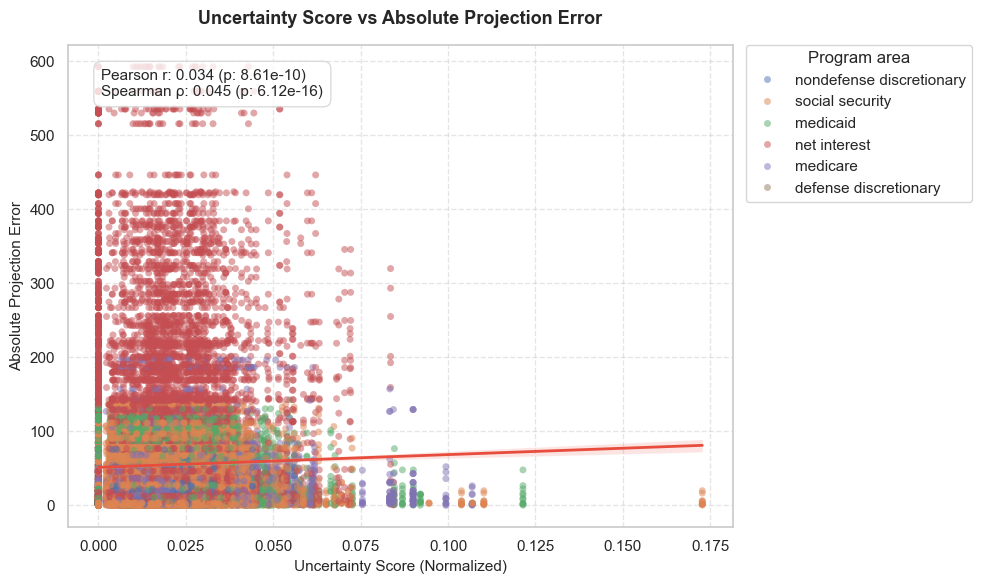

In [7]:
# ============================================================
# Correlation + plot across all projection horizons
# Colors by program area
# ============================================================

# Keep only needed columns and remove missing values
clean_corr_df = merged_df[
    ["contextual_uncertainty_score", "abs_projection_error", "subcategory"]
].dropna()

# Pearson correlation
pearson_coef, pearson_p = stats.pearsonr(
    clean_corr_df["contextual_uncertainty_score"],
    clean_corr_df["abs_projection_error"]
)

# Spearman correlation
spearman_coef, spearman_p = stats.spearmanr(
    clean_corr_df["contextual_uncertainty_score"],
    clean_corr_df["abs_projection_error"]
)

# Print results
print("=" * 50)
print("CORRELATION ANALYSIS RESULTS")
print("=" * 50)
print(f"Pearson Correlation Coefficient: {pearson_coef:.4f}")
print(
    f"Pearson p-value:                {pearson_p:.4e} "
    f"({'Statistically Significant' if pearson_p < 0.05 else 'Not Significant'})"
)
print("-" * 50)
print(f"Spearman Rank Correlation:       {spearman_coef:.4f}")
print(
    f"Spearman p-value:               {spearman_p:.4e} "
    f"({'Statistically Significant' if spearman_p < 0.05 else 'Not Significant'})"
)
print("=" * 50)

# Plot
plt.figure(figsize=(10, 6))

# Scatterplot colored by program area
sns.scatterplot(
    data=clean_corr_df,
    x="contextual_uncertainty_score",
    y="abs_projection_error",
    hue="subcategory",
    alpha=0.5,
    s=25,
    linewidth=0
)

# Overall regression line
sns.regplot(
    data=clean_corr_df,
    x="contextual_uncertainty_score",
    y="abs_projection_error",
    scatter=False,
    line_kws={"color": "#e74c3c", "linewidth": 2}
)

# Annotation
stats_text = (
    f"Pearson r: {pearson_coef:.3f} (p: {pearson_p:.2e})\n"
    f"Spearman ρ: {spearman_coef:.3f} (p: {spearman_p:.2e})"
)

plt.gca().text(
    0.05, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.8,
        edgecolor="lightgray"
    )
)

plt.title(
    "Uncertainty Score vs Absolute Projection Error",
    fontsize=13,
    fontweight="bold",
    pad=15
)
plt.xlabel("Uncertainty Score (Normalized)", fontsize=11)
plt.ylabel("Absolute Projection Error", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Legend outside plot
plt.legend(
    title="Program area",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [8]:
# Correlation coefficient for each subcategory
# 1. Drop rows missing either the uncertainty score or projection error
clean_df = merged_df[['subcategory', 'contextual_uncertainty_score', 'abs_projection_error']].dropna()

# 2. Group by subcategory and calculate Spearman correlation for each
sub_results = []

for subcat, group in clean_df.groupby('subcategory'):
    n_samples = len(group)
    
    # We need at least 3 data points to calculate a correlation coefficient
    if n_samples >= 3:
        coef, p_val = stats.spearmanr(group['contextual_uncertainty_score'], group['abs_projection_error'])
    else:
        coef, p_val = None, None
        
    sub_results.append({
        'subcategory': subcat,
        'sample_size': n_samples,
        'spearman_rho': coef,
        'p_value': p_val
    })

# 3. Convert results into a structured DataFrame
subcategory_correlations = pd.DataFrame(sub_results)

# 4. Add a quick visual indicator for statistical significance
def check_sig(p):
    if p is None:
        return 'Too few samples (<3)'
    elif p < 0.01:
        return 'Highly Significant (p < 0.01) **'
    elif p < 0.05:
        return 'Significant (p < 0.05) *'
    else:
        return 'Not Significant'

subcategory_correlations['significance'] = subcategory_correlations['p_value'].apply(check_sig)

# 5. Sort by the strongest absolute correlations first
subcategory_correlations['abs_rho'] = subcategory_correlations['spearman_rho'].abs()
subcategory_correlations = (
    subcategory_correlations
    .sort_values(by='abs_rho', ascending=False)
    .drop(columns=['abs_rho'])
    .reset_index(drop=True)
)

# Display the final summary table
subcategory_correlations

,subcategory,sample_size,spearman_rho,p_value,significance
0,medicaid,3715,-0.087941,7.931067e-08,Highly Significant (p < 0.01) **
1,medicare,4188,0.082818,7.996803e-08,Highly Significant (p < 0.01) **
2,net interest,6490,-0.034358,5.637584e-03,Highly Significant (p < 0.01) **
3,nondefense discretionary,2468,0.011966,5.524085e-01,Not Significant
4,social security,15822,-0.011211,1.585096e-01,Not Significant
5,defense discretionary,278,0.000574,9.923921e-01,Not Significant


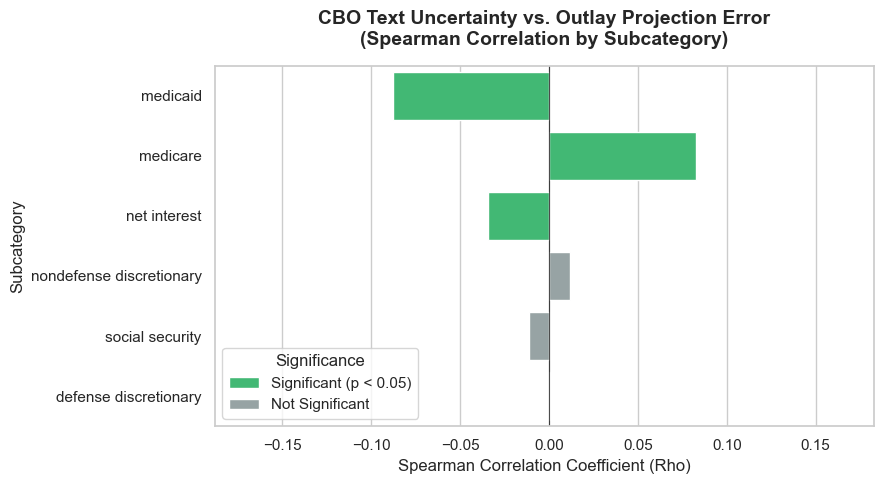

In [9]:
# Visualize the correlations for each subcategory above
# 1. Prepare your data for visualization
# Filter out any subcategories that didn't have enough samples to calculate correlation
viz_df = subcategory_correlations.dropna(subset=['spearman_rho']).copy()

# Sort by the strength of the correlation (absolute value) so the strongest relationships are at the top
viz_df['abs_rho'] = viz_df['spearman_rho'].abs()
viz_df = viz_df.sort_values(by='abs_rho', ascending=False)

# Add a grouping column specifically for plotting color schemes
viz_df['Significance'] = viz_df['p_value'].apply(
    lambda p: 'Significant (p < 0.05)' if p < 0.05 else 'Not Significant'
)

# 2. Set up the plotting canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# 3. Create a horizontal barplot
# Greens signify reliable signals; Greys signify no reliable relationship.
sns.barplot(
    data=viz_df,
    x='spearman_rho',
    y='subcategory',
    hue='Significance',
    palette={
        'Significant (p < 0.05)': '#2ecc71',  # Clear emerald green
        'Not Significant': '#95a5a6'          # Muted slate grey
    },
    dodge=False
)

# 4. Enhance the chart details
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)  # Zero correlation reference line
plt.title('CBO Text Uncertainty vs. Outlay Projection Error\n(Spearman Correlation by Subcategory)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Spearman Correlation Coefficient (Rho)', fontsize=12)
plt.ylabel('Subcategory', fontsize=12)

# Adjust the x-axis limits to leave a little breathing room
min_val = viz_df['spearman_rho'].min()
max_val = viz_df['spearman_rho'].max()
plt.xlim(min_val - 0.1 if min_val < 0 else -0.1, max_val + 0.1 if max_val > 0 else 0.1)

plt.tight_layout()
plt.show()

In [10]:
# Correlation coefficient for each subcategory for only projected horizons 3, 6, and 9 
# 1. Filter for your target horizons and drop missing values
target_horizons = [3, 6, 9]
horizon_df = merged_df[
    (merged_df['projection_horizon_years'].isin(target_horizons)) & 
    (merged_df['contextual_uncertainty_score'].notna()) & 
    (merged_df['abs_projection_error'].notna())
].copy()

horizon_results = []

# 2. Group by both subcategory and the horizon year
for (subcat, horizon), group in horizon_df.groupby(['subcategory', 'projection_horizon_years']):
    n_samples = len(group)
    
    # Ensure there are enough data points to compute a valid correlation
    if n_samples >= 3:
        coef, p_val = stats.spearmanr(group['contextual_uncertainty_score'], group['abs_projection_error'])
    else:
        coef, p_val = None, None
        
    horizon_results.append({
        'subcategory': subcat,
        'projection_horizon_years': horizon,
        'sample_size': n_samples,
        'spearman_rho': coef,
        'p_value': p_val
    })

# 3. Build a clean results DataFrame
horizon_corr_df = pd.DataFrame(horizon_results)

# 4. Add statistical significance flags
def check_sig(p):
    if p is None:
        return 'Too few samples (<3)'
    return 'Significant (p < 0.05)' if p < 0.05 else 'Not Significant'

horizon_corr_df['Significance'] = horizon_corr_df['p_value'].apply(check_sig)

# Sort logically by subcategory and horizon milestone
horizon_corr_df = horizon_corr_df.sort_values(by=['subcategory', 'projection_horizon_years']).reset_index(drop=True)

# Display the summary table
horizon_corr_df

,subcategory,projection_horizon_years,sample_size,spearman_rho,p_value,Significance
0,defense discretionary,3,28,0.011952,0.951866,Not Significant
1,defense discretionary,6,25,-0.358015,0.078882,Not Significant
2,defense discretionary,9,22,0.194156,0.386603,Not Significant
3,medicaid,3,365,-0.202755,0.000096,Significant (p < 0.05)
4,medicaid,6,334,-0.121458,0.026444,Significant (p < 0.05)
5,medicaid,9,287,-0.218602,0.000190,Significant (p < 0.05)
6,medicare,3,397,0.126835,0.011425,Significant (p < 0.05)
7,medicare,6,374,0.070809,0.171777,Not Significant
8,medicare,9,357,0.149162,0.004739,Significant (p < 0.05)
9,net interest,3,654,-0.167180,0.000017,Significant (p < 0.05)


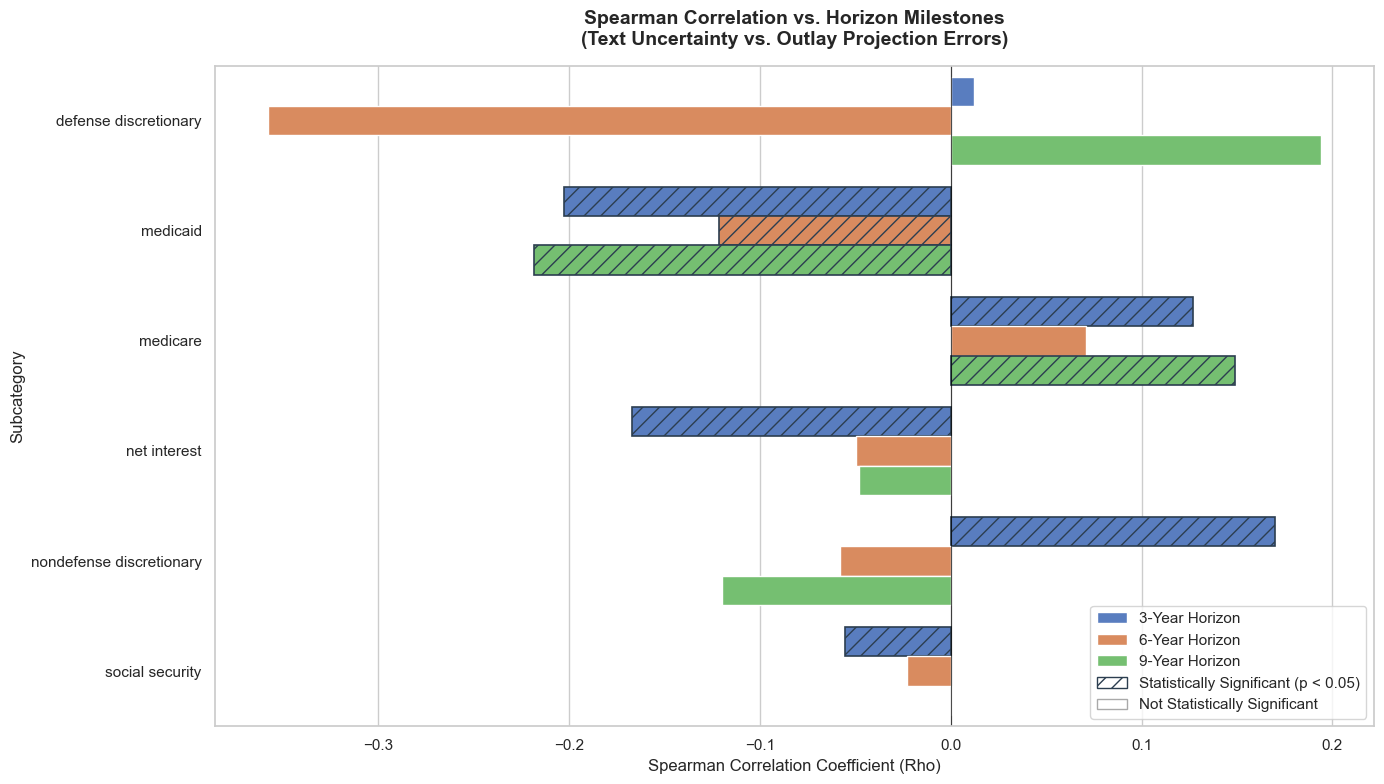

In [11]:
# Visualizations for each subcategory above for projected horizons 3,6 and 9
# 1. Clean and structurally sort data to align perfectly with Seaborn's patch order
viz_horizon_df = horizon_corr_df.dropna(subset=['spearman_rho']).copy()

# Standardize text for the legend label
viz_horizon_df['horizon_label'] = viz_horizon_df['projection_horizon_years'].astype(str) + '-Year Horizon'

# Establish strict categorical order so hue blocks match our loops perfectly
horizon_order = ['3-Year Horizon', '6-Year Horizon', '9-Year Horizon']
subcategory_order = sorted(viz_horizon_df['subcategory'].unique())

viz_horizon_df['horizon_label'] = pd.Categorical(viz_horizon_df['horizon_label'], categories=horizon_order, ordered=True)
viz_horizon_df['subcategory'] = pd.Categorical(viz_horizon_df['subcategory'], categories=subcategory_order, ordered=True)

# Sort strictly by the grouping rules of seaborn (hue group first, then category)
viz_horizon_df = viz_horizon_df.sort_values(by=['horizon_label', 'subcategory']).reset_index(drop=True)

# 2. Canvas Setup
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Draw the Grouped Bar Plot
sns.barplot(
    data=viz_horizon_df,
    x='spearman_rho',
    y='subcategory',
    hue='horizon_label',
    palette='muted',
    ax=ax
)

# 4. Iterate over individual bar patches to inject the significance texture
# Seaborn generates patches sequentially matching our sorted dataframe rows
for patch, significance_status in zip(ax.patches, viz_horizon_df['Significance']):
    if significance_status == 'Significant (p < 0.05)':
        patch.set_hatch('//')         # Apply clear diagonal stripes
        patch.set_edgecolor('#2c3e50') # Give significant bars a subtle crisp border
        patch.set_linewidth(1.2)

# 5. Graph Framing & Legends
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

plt.title('Spearman Correlation vs. Horizon Milestones\n(Text Uncertainty vs. Outlay Projection Errors)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Spearman Correlation Coefficient (Rho)', fontsize=12)
plt.ylabel('Subcategory', fontsize=12)

# Create custom manual legend elements to explain the texture difference
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor='#2c3e50', hatch='//', label='Statistically Significant (p < 0.05)'),
    Patch(facecolor='none', edgecolor='darkgray', label='Not Statistically Significant')
]

# Merge our new significance legend items with the original horizon milestone colors
original_legend = ax.get_legend()
original_title = original_legend.get_title().get_text() if original_legend.get_title() else 'Forecast Horizon'
handles, labels = ax.get_legend_handles_labels()

# Draw unified double-layered legend
plt.legend(
    handles=handles + legend_elements, 
    labels=labels + [el.get_label() for el in legend_elements],
    loc='lower right', 
    frameon=True, 
    facecolor='white'
)

plt.tight_layout()
plt.show()